In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\safee\OneDrive\Desktop\IBM HR Attriton\data\IBM Dataset.csv")

# Display data
df.head()
df.tail()

# Dataset information
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.info())

# Statistical summary
df.describe()
print(df.describe(include="object"))

# Data quality
print(df.isnull().sum())
print(df.duplicated().sum())

# Unique values
print(df.nunique())
print(df["Department"].unique())
print(df["Department"].value_counts())

# Sample data
print(df.sample(5))

# Memory usage
print(df.memory_usage())
#defines the shape of the dataset, the number of rows and columns
df.shape 
#displays the column names of the dataset
df.columns
#displays information about the dataset
df.info()
#displays statistical summary of the dataset
df.describe()
#displays statistical summary of object columns
df.describe(include='object')
#displays the number of missing values in each column
df.isnull().sum()
#displays the number of duplicate rows
df.duplicated().sum()
#tells the data types of each column
df.dtypes
#finds the number of unique values in each column
df.nunique()
#displays sample of 5 rows from the dataset
df.sample(5)

#Creating a copy of the dataset for cleaning and preprocessing
df_clean = df.copy()
df_clean.nunique().sort_values()
df_clean.drop(
    columns=[
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ],
    inplace=True
)
df_clean.columns.tolist()
df_clean["EmployeeNumber"].head()
df_clean.drop(columns="EmployeeNumber", inplace=True)
df_clean.shape
df_clean.isnull().sum()
df_clean.duplicated().sum()

(1470, 35)
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              objec

np.int64(0)

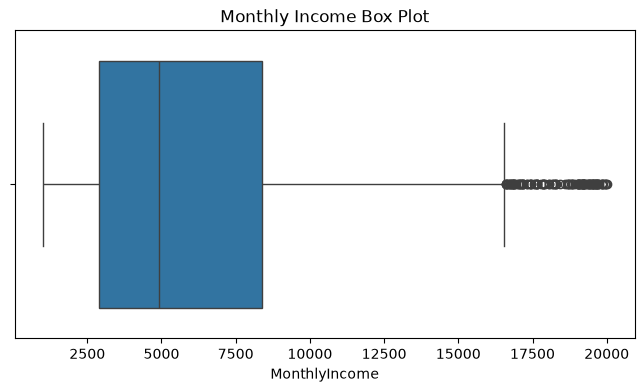

Q1: 2911.0
Q3: 8379.0
IQR: 5468.0
Lower Limit: -5291.0
Upper Limit: 16581.0
Number of outliers: 114


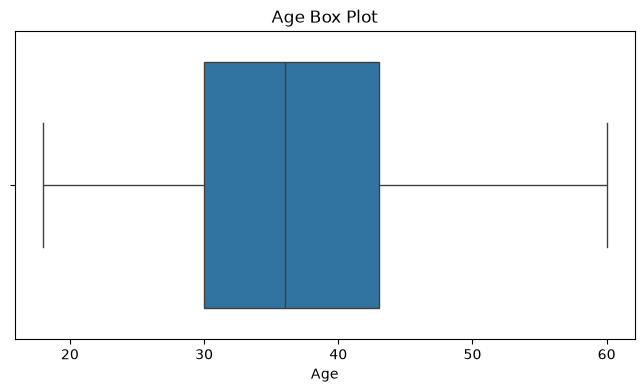

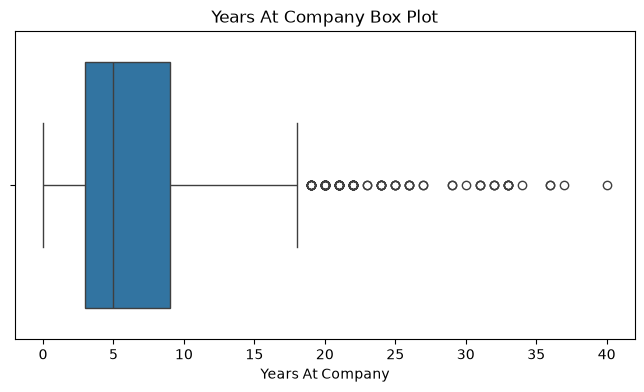

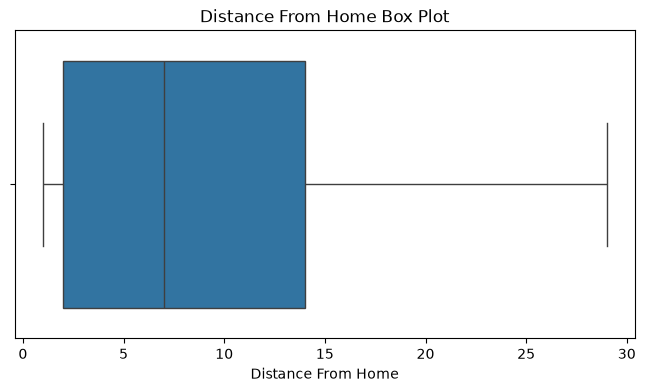

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns
#box plot for Monthly Income
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["MonthlyIncome"])
plt.title("Monthly Income Box Plot")
plt.show()

Q1 = df_clean["MonthlyIncome"].quantile(0.25)
Q3 = df_clean["MonthlyIncome"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = df_clean[
    (df_clean["MonthlyIncome"] < lower_limit) |
    (df_clean["MonthlyIncome"] > upper_limit)
]

print("Number of outliers:", len(outliers))

#Box Plot for Age
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["Age"])
plt.title("Age Box Plot")
plt.xlabel("Age")
plt.show()

#box plot for Years At Company
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["YearsAtCompany"])
plt.title("Years At Company Box Plot")
plt.xlabel("Years At Company")
plt.show()

#Box Plot for Distance From Home
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["DistanceFromHome"])
plt.title("Distance From Home Box Plot")
plt.xlabel("Distance From Home")
plt.show()


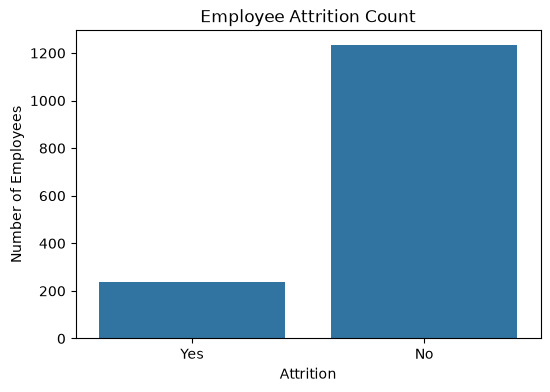

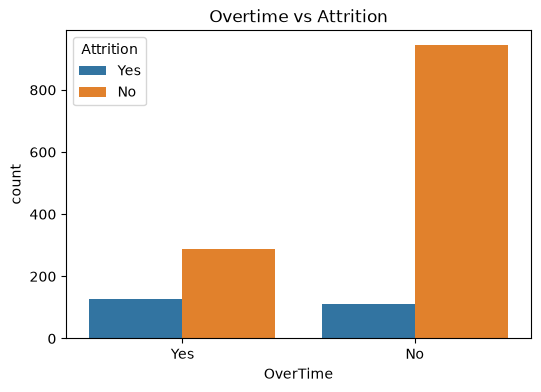

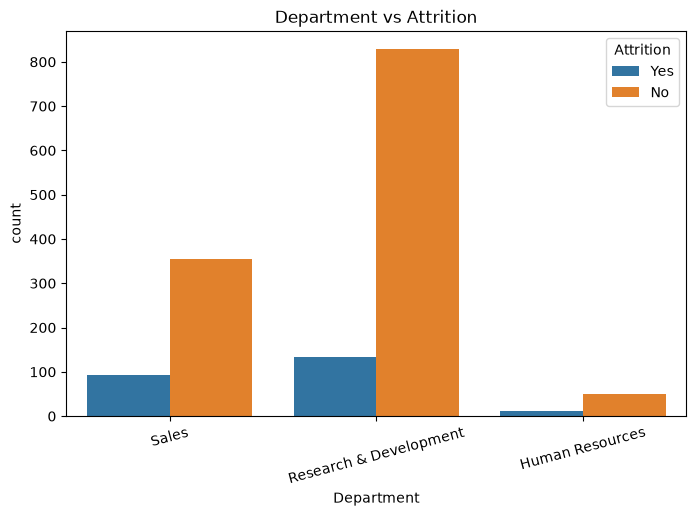

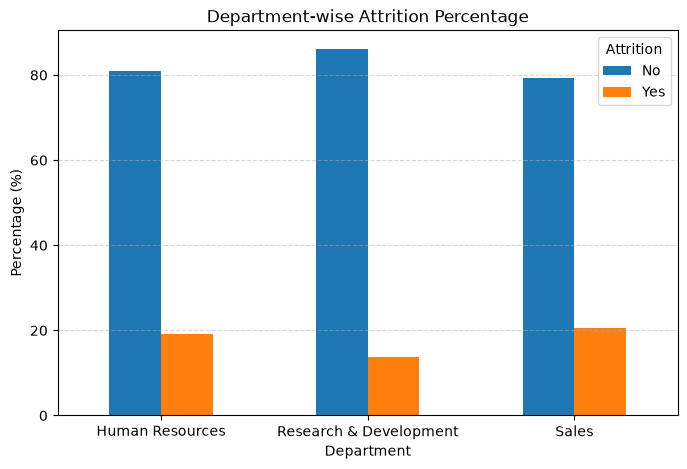

In [3]:
#EDA Analysis
#Employees left the company
df_clean["Attrition"].value_counts()

#No : 1233
#Yes : 237

#percentage of employees who left the company
df_clean["Attrition"].value_counts(normalize=True) * 100 

#Visualization of Attrition
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="Attrition")
plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

#Overtime vs Attrition
pd.crosstab(df_clean["OverTime"], df_clean["Attrition"])
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_clean,
    x="OverTime",
    hue="Attrition"
)
plt.title("Overtime vs Attrition")
plt.show()

#Department vs Attrition
pd.crosstab(df_clean["Department"], df_clean["Attrition"])
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Department", hue="Attrition")
plt.title("Department vs Attrition")
plt.xticks(rotation=15)
plt.show()

#Attrition rate by Department
department_attrition = pd.crosstab(
    df_clean["Department"],
    df_clean["Attrition"],
    normalize="index"
) * 100

department_attrition

#visulaization of attrition rate by department
department_attrition.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Department-wise Attrition Percentage")
plt.ylabel("Percentage (%)")
plt.xlabel("Department")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

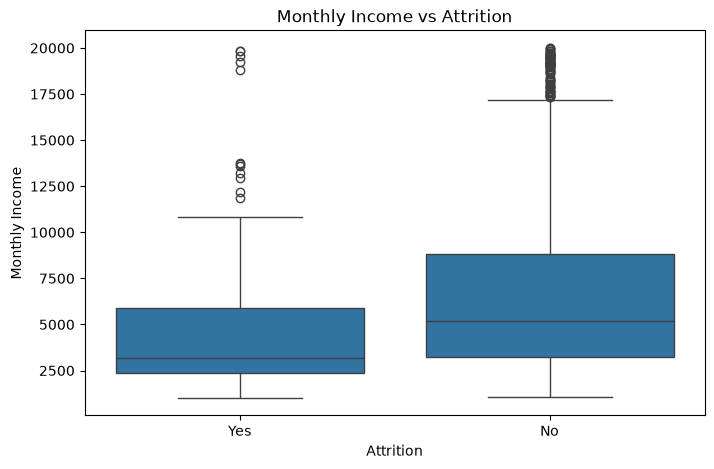

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64


In [4]:
#Salary vs Attrition
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

#Average Monthly Income by Attrition
print(df_clean.groupby("Attrition")["MonthlyIncome"].mean())

Why box plot for the above graph
It lets us compare the salary distribution between:

Employees who stayed (No)
Employees who left (Yes)

We'll look for differences in:

Median salary
Spread of salaries
Outliers

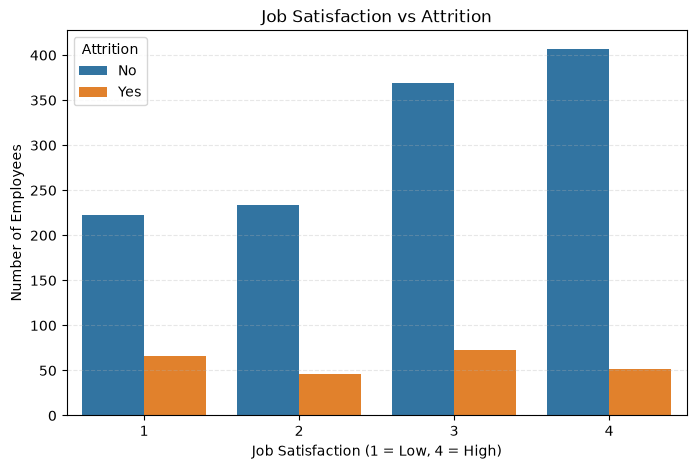

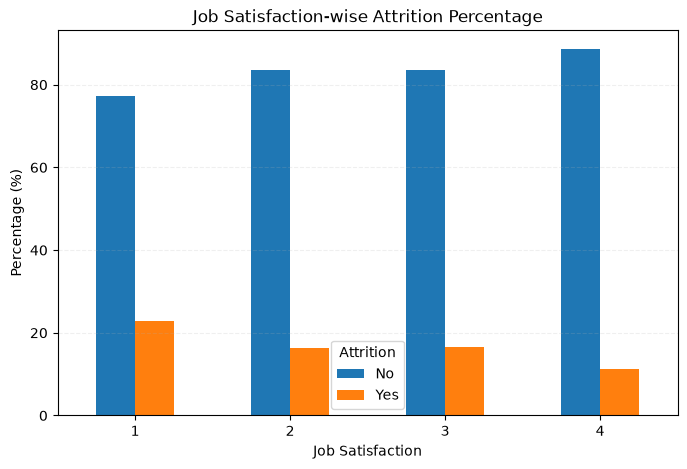

In [5]:
#Job Satisfaction vs Attrition
pd.crosstab(df_clean["JobSatisfaction"], df_clean["Attrition"])
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Job Satisfaction (1 = Low, 4 = High)")
plt.ylabel("Number of Employees")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

#Understanding by the percntage of employees who left the company based on their job satisfaction level
job_sat_attrition = pd.crosstab(
    df_clean["JobSatisfaction"],
    df_clean["Attrition"],
    normalize="index"
) * 100

job_sat_attrition

#Visualisation
job_sat_attrition.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Job Satisfaction-wise Attrition Percentage")
plt.xlabel("Job Satisfaction")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.2)
plt.show()

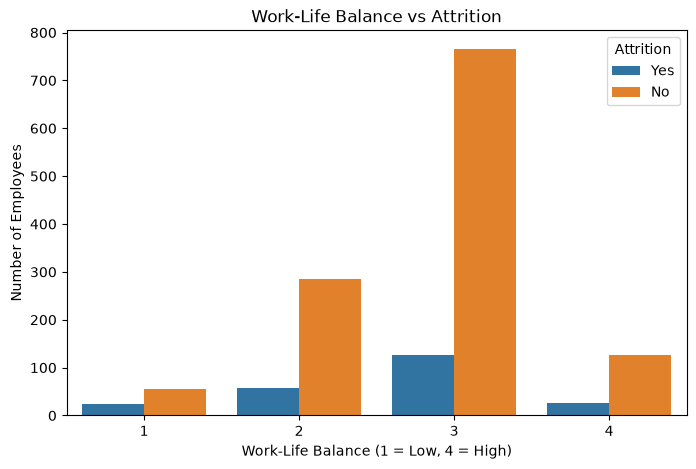

In [6]:
#Wroklife Balance vs Attrition
pd.crosstab(df_clean["WorkLifeBalance"], df_clean["Attrition"])
#percentage
worklife_attrition = pd.crosstab(
    df_clean["WorkLifeBalance"],
    df_clean["Attrition"],
    normalize="index"
) * 100

worklife_attrition

#Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance vs Attrition")
plt.xlabel("Work-Life Balance (1 = Low, 4 = High)")
plt.ylabel("Number of Employees")

plt.show()

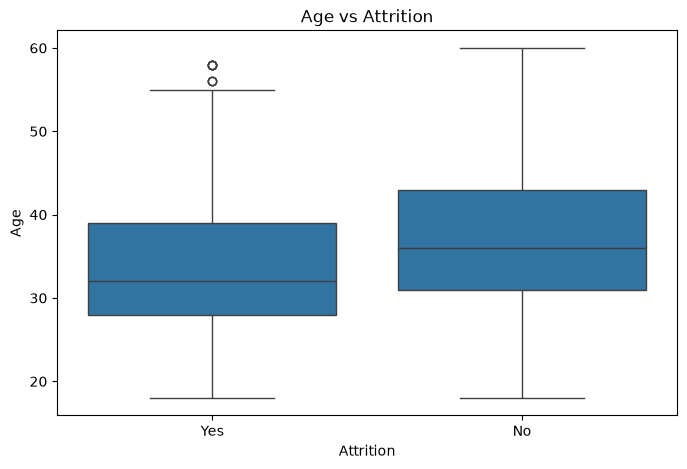

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64

In [7]:
#Age vs Attrition
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="Age"
)

plt.title("Age vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

#Average Age by Attrition
df_clean.groupby("Attrition")["Age"].mean()

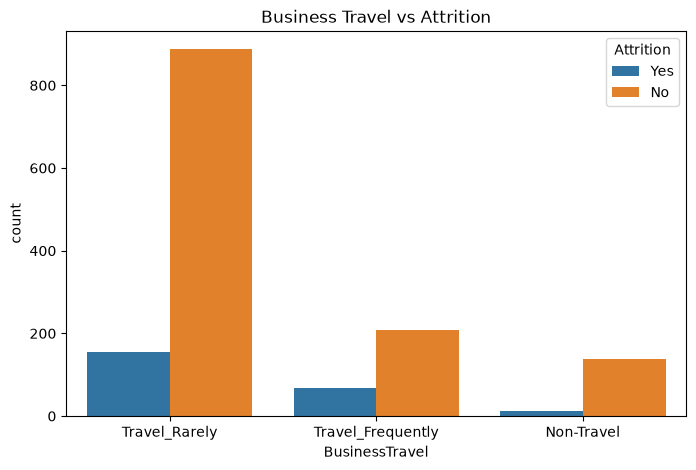

In [8]:
#Buisness Travel vs Attrition
pd.crosstab(df_clean["BusinessTravel"], df_clean["Attrition"])
#percentage
travel_attrition = pd.crosstab(
    df_clean["BusinessTravel"],
    df_clean["Attrition"],
    normalize="index"
) * 100

travel_attrition
#Visualization
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_clean,
    x="BusinessTravel",
    hue="Attrition"
)
plt.title("Business Travel vs Attrition")
plt.show()

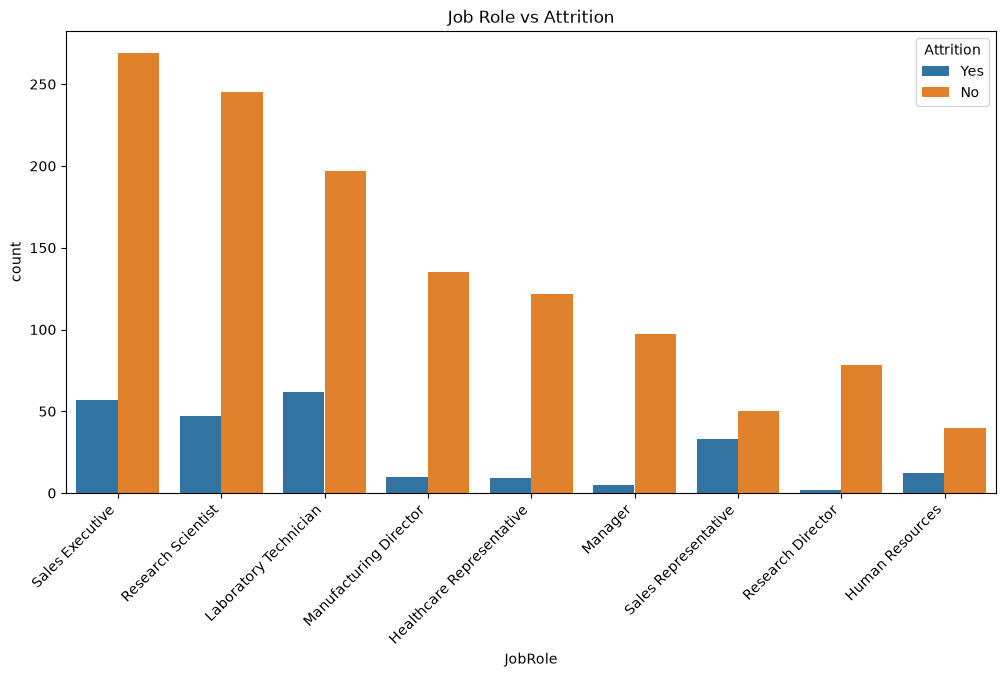

In [9]:
#job role vs attrition
pd.crosstab(df_clean["JobRole"], df_clean["Attrition"])
#percentage
role_attrition = pd.crosstab(
    df_clean["JobRole"],
    df_clean["Attrition"],
    normalize="index"
) * 100

role_attrition
#visualization
plt.figure(figsize=(12,6))
sns.countplot(
    data=df_clean,
    x="JobRole",
    hue="Attrition"
)

plt.xticks(rotation=45, ha="right")
plt.title("Job Role vs Attrition")
plt.show()

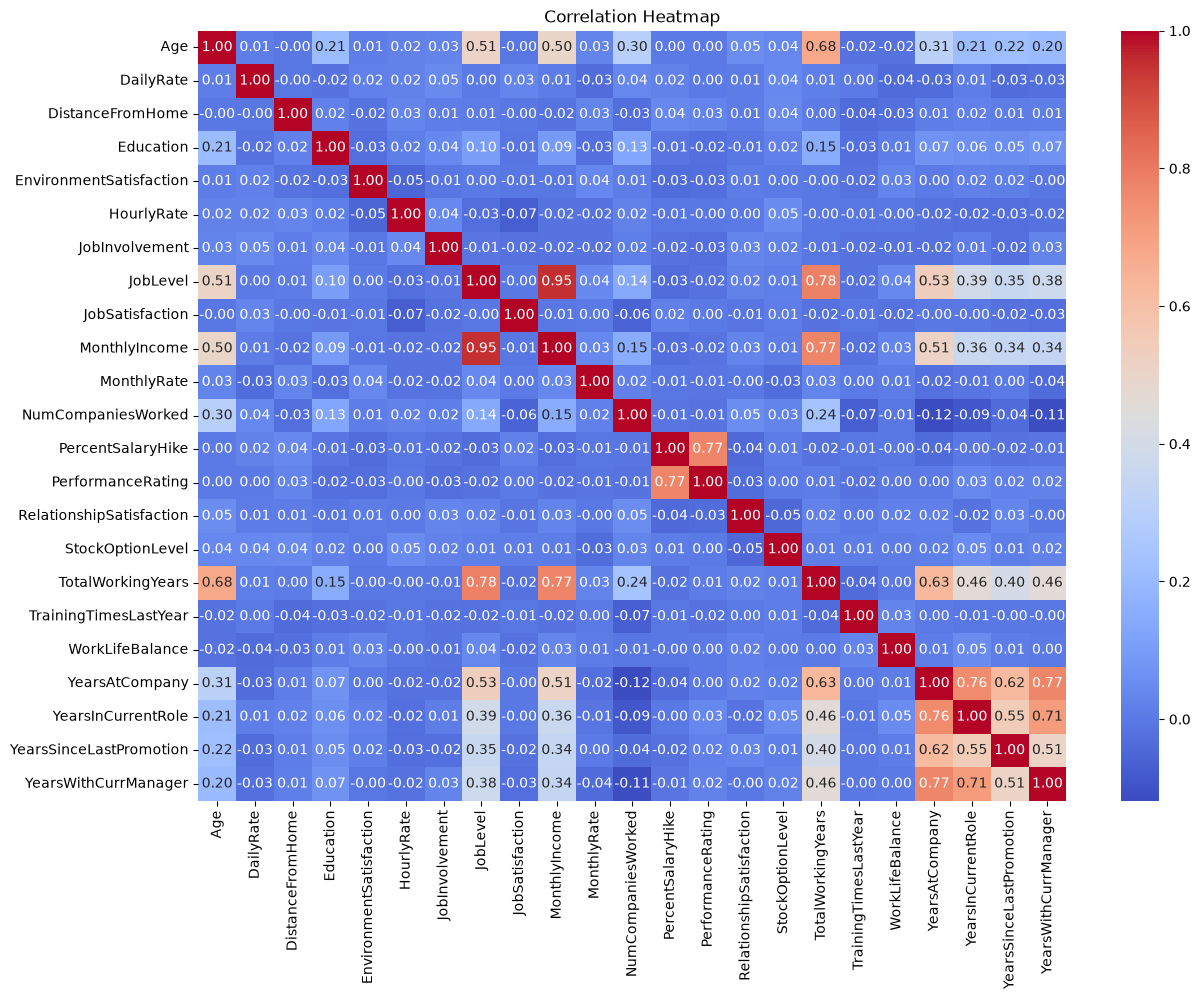

In [10]:
#correlation between numerical variables
correlation = df_clean.corr(numeric_only=True)
correlation

#Heatmap of correlation matrix
plt.figure(figsize=(14,10))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

Why Heatmap Is important
It helps identify:

Strong positive correlations (close to +1)
Strong negative correlations (close to -1)
Weak or no correlation (close to 0)

For example:

Does MonthlyIncome increase with TotalWorkingYears?
Are YearsAtCompany and YearsInCurrentRole related?
Does Age correlate with MonthlyIncome?

These insights are valuable for both interviews and your Power BI dashboard.

In [11]:
df_clean
df_clean.to_csv(
    r"C:\Users\safee\OneDrive\Desktop\IBM HR Attriton\data\IBM_HR_Cleaned.csv",
    index=False
)
import os

os.path.exists(
    r"C:\Users\safee\OneDrive\Desktop\IBM HR Attriton\data\IBM_HR_Cleaned.csv"
)

True